# RoomCraft AI
## Proyecto Final — IA: Entretejiendo Imaginación y Algoritmos

**Alumno:** Felix Reyno  
**Materia:** IA: Generación de Prompts

## Resumen

RoomCraft AI es una propuesta que asiste a personas sin conocimientos de diseño de interiores a planificar la remodelación o decoración de un ambiente, combinando dos modelos de Inteligencia Artificial: un modelo de texto que genera una recomendación de diseño personalizada (distribución, muebles, colores, iluminación, materiales) a partir de los datos del ambiente, y un modelo de texto a imagen que genera una representación visual de esa propuesta. Este notebook documenta el problema abordado, la solución propuesta, y una prueba de concepto (POC) funcional de ambas etapas.

## Introducción

**Nombre del proyecto:** RoomCraft AI

**Presentación del problema:** Muchas personas desean remodelar o decorar un espacio de su hogar (una habitación, un living, una cocina) pero no cuentan con conocimientos de diseño de interiores ni con presupuesto para contratar a un profesional. Esto genera dificultades para combinar colores, distribuir muebles y aprovechar el espacio disponible, y buscar inspiración genérica en internet no siempre resuelve las necesidades puntuales de cada usuario.

**Propuesta de solución:** RoomCraft AI parte de los datos de un ambiente (tipo, dimensiones, estilo, presupuesto, colores preferidos y objetivo principal) y los traduce en dos prompts encadenados: primero, un prompt de texto que le pide a un modelo de lenguaje una recomendación de diseño completa y justificada; luego, un prompt de imagen construido a partir de esa misma recomendación, que genera una representación visual del ambiente propuesto.

**Viabilidad:** el proyecto es viable porque no requiere entrenar ningún modelo propio: usa modelos de lenguaje ya existentes a través de prompts. La primera etapa (texto) se resuelve mediante la API de Groq, que ofrece acceso gratuito sin tarjeta de crédito. La segunda etapa (imagen) se resuelve con una herramienta gratuita de generación de imágenes (como Nightcafe), ya que Dall-E dejó de ser gratuita.

## Objetivos

- Identificar una problemática concreta vinculada al diseño de interiores y plantear una solución basada en IA.
- Generar un prompt de texto que produzca una recomendación de diseño completa, específica y justificada.
- Generar un prompt de imagen, derivado de la recomendación de texto, que represente visualmente el ambiente propuesto.
- Evaluar la factibilidad y las limitaciones de la solución.

## Metodología

1. Se definen los datos de entrada del ambiente a diseñar (tipo, dimensiones, estilo, presupuesto, colores, objetivo).
2. Con esos datos se arma un prompt de texto dirigido a un modelo de lenguaje (Groq, `openai/gpt-oss-20b`), pidiendo una salida organizada en distribución, muebles, paleta de colores, iluminación, materiales, tips de espacio y lista de elementos.
3. A partir de esa recomendación (específicamente, del estilo, la paleta de colores y la distribución) se arma un segundo prompt, esta vez para un modelo de texto a imagen.
4. Ese segundo prompt se ejecuta manualmente en una herramienta gratuita de generación de imágenes (Nightcafe u otra alternativa), ya que no se cuenta con acceso a la API de Dall-E.
5. Se documentan ambos resultados (texto e imagen) en este notebook.

## Herramientas y tecnologías

- **Python** como lenguaje de implementación.
- **Groq** (API compatible con OpenAI) como proveedor del modelo de texto, usando el modelo `openai/gpt-oss-20b`. Se eligió por tener un nivel gratuito sin necesidad de tarjeta de crédito.
- **Pydantic** y **JSON Schema en modo estricto** para forzar una salida organizada y validada (salida dirigida), en vez de un texto libre.
- **Nightcafe** (u otra herramienta gratuita equivalente) para la generación de la imagen, dado que Dall-E dejó de ofrecer acceso gratuito.
- Técnicas de prompting aplicadas: asignación de rol ("actuá como un diseñador profesional de interiores"), especificación explícita de restricciones (dimensiones, estilo, presupuesto, colores, objetivo), y encadenamiento de prompts (el resultado del primer prompt alimenta al segundo).

## Implementación

In [2]:
!pip install -q groq pydantic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.8/143.8 kB 5.7 MB/s eta 0:00:00


In [3]:
import json
import os
from typing import List

from groq import Groq
from pydantic import BaseModel

try:
    from google.colab import userdata
    api_key = userdata.get("GROQ_API_KEY")
except ImportError:
    api_key = os.getenv("GROQ_API_KEY")

cliente = Groq(api_key=api_key)

In [4]:
class RecomendacionDiseno(BaseModel):
    distribucion: str
    muebles: List[str]
    paleta_colores: List[str]
    iluminacion: List[str]
    materiales: List[str]
    tips_espacio: List[str]
    lista_elementos: List[str]


ESQUEMA = {
    "type": "object",
    "properties": {
        "distribucion": {"type": "string"},
        "muebles": {"type": "array", "items": {"type": "string"}},
        "paleta_colores": {"type": "array", "items": {"type": "string"}},
        "iluminacion": {"type": "array", "items": {"type": "string"}},
        "materiales": {"type": "array", "items": {"type": "string"}},
        "tips_espacio": {"type": "array", "items": {"type": "string"}},
        "lista_elementos": {"type": "array", "items": {"type": "string"}},
    },
    "required": [
        "distribucion", "muebles", "paleta_colores", "iluminacion",
        "materiales", "tips_espacio", "lista_elementos",
    ],
    "additionalProperties": False,
}


def generar_recomendacion(tipo_ambiente, dimensiones, estilo, presupuesto, colores, objetivo):
    prompt = f"""Actúa como un diseñador profesional de interiores.
Diseña un/a {tipo_ambiente} de {dimensiones} m² pensado para {objetivo}.
El estilo debe ser {estilo}, utilizando colores {colores}.
El presupuesto máximo es de {presupuesto} dólares.
Explicá la distribución recomendada, justificá cada decisión y sugerí
muebles funcionales y accesibles."""

    respuesta = cliente.chat.completions.create(
        model="openai/gpt-oss-20b",
        messages=[{"role": "user", "content": prompt}],
        response_format={
            "type": "json_schema",
            "json_schema": {"name": "recomendacion", "strict": True, "schema": ESQUEMA},
        },
        max_tokens=2000,
    )

    crudo = json.loads(respuesta.choices[0].message.content)
    return RecomendacionDiseno.model_validate(crudo)

### Prueba de concepto: generamos una recomendación de ejemplo

In [8]:
recomendacion = generar_recomendacion(
    tipo_ambiente="habitación",
    dimensiones=12,
    estilo="escandinavo",
    presupuesto=800,
    colores="blanco y madera clara",
    objetivo="un estudiante universitario que quiere descansar y estudiar",
)

print("DISTRIBUCIÓN:\n", recomendacion.distribucion, "\n")
print("MUEBLES:", recomendacion.muebles, "\n")
print("PALETA DE COLORES:", recomendacion.paleta_colores, "\n")
print("ILUMINACIÓN:\n", recomendacion.iluminacion, "\n")
print("MATERIALES:", recomendacion.materiales, "\n")
print("TIPS DE ESPACIO:", recomendacion.tips_espacio, "\n")
print("LISTA DE ELEMENTOS:", recomendacion.lista_elementos)

DISTRIBUCIÓN:
 Cama plataforma con cajones en el centro, mesa de estudio plegable sobre la pared opuesta, estantería modular en la pared lateral, silla ergonómica frente a la mesa, espejo de pie junto al armario. La luz natural se maximiza con cortina de lino ligera, y la iluminación artificial incluye lámpara de escritorio LED y lámpara de techo LED regulable. Esta distribución aprovecha el espacio vertical y permite separar áreas de estudio y descanso sin ocupar mucho suelo. 

MUEBLES: ['cama plataforma con cajones', 'mesa de estudio plegable', 'silla ergonómica', 'estantería modular de estantes ajustables', 'espejo de pie'] 

PALETA DE COLORES: ['blanco', 'madera clara'] 

ILUMINACIÓN:
 ['lámpara de escritorio LED', 'lámpara de techo LED regulable', 'cortina de lino natural'] 

MATERIALES: ['MDF con acabado claro', 'pintura blanca lavable', 'tela de lino', 'metálico ligero'] 

TIPS DE ESPACIO: ['Usar muebles multifuncionales para ahorrar espacio', 'Colocar espejos para ampliar visua

### Del texto a la imagen

A partir de la recomendación anterior, se arma un segundo prompt para un modelo de texto a imagen, combinando el estilo, la paleta de colores y algunos de los muebles sugeridos:

> "Habitación de 12 m² con estilo escandinavo, paredes blancas, piso de madera clara, escritorio junto a una ventana, cama con ropa de cama blanca, iluminación cálida, plantas decorativas y repisas flotantes. Diseño moderno, realista y luminoso."

Este prompt se generó manualmente en **Nightcafe** (nightcafe.studio), ya que Dall-E dejó de ofrecer acceso gratuito. El resultado se agrega como imagen a continuación.

In [6]:
from google.colab import files
subido = files.upload()

Saving cuarto.jpg to cuarto (1).jpg


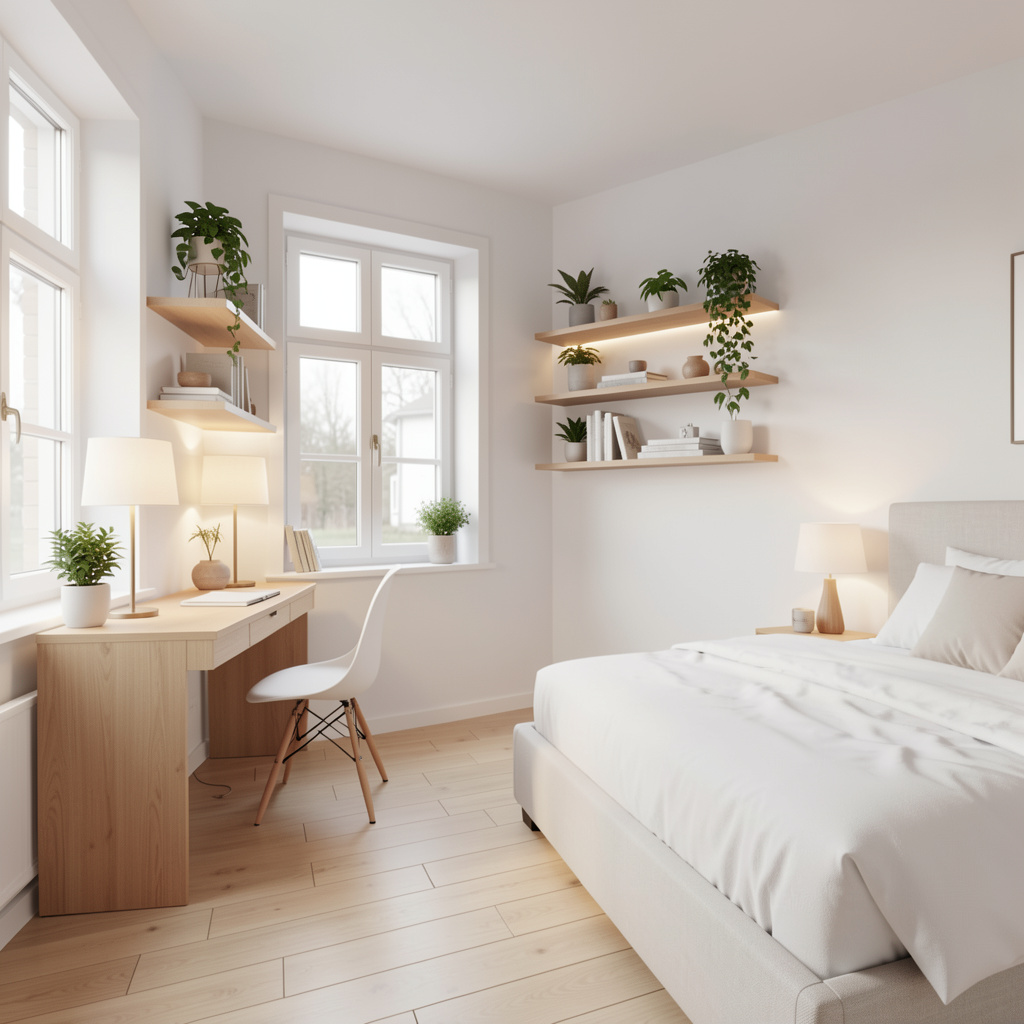

In [7]:
from IPython.display import Image, display
nombre_archivo = list(subido.keys())[0]
display(Image(filename=nombre_archivo))

## Resultados

La implementación genera, a partir de los datos de un ambiente, una recomendación de diseño organizada en 7 componentes (distribución, muebles, paleta de colores, iluminación, materiales, tips de espacio y lista de elementos), validada mediante un esquema JSON estricto que garantiza que la respuesta esté siempre completa y en el formato esperado.


Como limitación, el modelo no tiene comprensión espacial real: las dimensiones y la distribución son orientativas, no un plano preciso. Tampoco puede verificar precios de mercado actuales, por lo que el presupuesto funciona como una restricción del prompt, no como una cotización garantizada.

## Conclusiones

Elegí este problema porque lo viví en carne propia: en más de una ocasión necesité remodelar una habitación o un living y no tenía en claro cuál era el presupuesto necesario ni qué cambios entraban dentro de ese presupuesto. RoomCraft AI busca resolver exactamente esa incertidumbre, combinando una recomendación de texto con una visualización generada por IA, sin necesidad de contratar a un profesional.

Si esta solución se usara en un contexto real, el principal impacto sería el ahorro de tiempo y dinero: en lugar de pagar una consulta de asesoramiento, el usuario obtendría en minutos una primera propuesta concreta, con una imagen orientativa, adaptada a su espacio, su estilo y su presupuesto.

Se cumplieron los objetivos planteados: se identificó una problemática concreta, se generó un prompt de texto con salida validada, y se derivó de él un prompt de imagen coherente con la recomendación.

## Referencias

- Documentación de Groq: https://console.groq.com/docs
- Documentación de Pydantic: https://docs.pydantic.dev
- Nightcafe (generación de imágenes): https://creator.nightcafe.studio